# Adversarial Robustness Evaluation in Deep Learning

## Overview

This notebook studies the robustness of deep learning models against adversarial attacks.

The experiments evaluate model vulnerability under adversarial perturbations and investigate adversarial training as a mitigation strategy.

Methods covered:

- FGSM attack
- PGD attack
- Adversarial training
- Robustness evaluation

## Problem Definition

Deep learning models can achieve high accuracy on clean data but may become vulnerable to carefully crafted adversarial examples.

This experiment investigates:

- How adversarial perturbations affect model performance
- How different attack strategies degrade accuracy
- How adversarial training improves model robustness

## Experimental Setup

Dataset:
- CIFAR-10

Model:
- Pretrained ResNet-20

Evaluation:

- Clean accuracy
- Adversarial accuracy
- Robustness comparison

In [5]:
!pip install -q torch torchvision matplotlib pandas tqdm

## PGD Attack

Projected Gradient Descent (PGD) applies iterative adversarial perturbations.

Compared with FGSM, PGD performs multiple optimization steps to generate stronger adversarial examples.

In [6]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from tqdm.auto import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

OUTPUT_DIR = "/content/q4_adversarial_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

EPSILON = 8 / 255
ALPHA = 2 / 255
PGD_STEPS = 10

BATCH_SIZE = 128
NUM_WORKERS = 2

TRAIN_SUBSET_SIZE = 20000
ADV_TRAIN_EPOCHS = 3
ADV_RATIO = 0.5

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2023, 0.1994, 0.2010)

print("Device:", DEVICE)
print("Output directory:", OUTPUT_DIR)
print("epsilon:", EPSILON)
print("alpha:", ALPHA)
print("PGD steps:", PGD_STEPS)

Device: cpu
Output directory: /content/q4_adversarial_outputs
epsilon: 0.03137254901960784
alpha: 0.00784313725490196
PGD steps: 10


In [4]:
DATA_ROOT = "/content/data"
CIFAR_FOLDER = os.path.join(DATA_ROOT, "cifar-10-batches-py")
CIFAR_TAR = os.path.join(DATA_ROOT, "cifar-10-python.tar.gz")

os.makedirs(DATA_ROOT, exist_ok=True)

if not os.path.exists(CIFAR_FOLDER):
    !apt-get -qq update
    !apt-get -qq install -y aria2
    !aria2c -x 8 -s 8 -k 1M --continue=true -d /content/data -o cifar-10-python.tar.gz https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz

    import tarfile
    with tarfile.open(CIFAR_TAR, "r:gz") as tar:
        tar.extractall(path=DATA_ROOT)

test_transform = transforms.ToTensor()

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

train_dataset_full = datasets.CIFAR10(
    root=DATA_ROOT,
    train=True,
    download=False,
    transform=train_transform
)

test_dataset = datasets.CIFAR10(
    root=DATA_ROOT,
    train=False,
    download=False,
    transform=test_transform
)

rng = np.random.default_rng(SEED)

train_indices = rng.choice(
    len(train_dataset_full),
    size=min(TRAIN_SUBSET_SIZE, len(train_dataset_full)),
    replace=False
)

train_dataset = Subset(train_dataset_full, train_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

class_names = test_dataset.classes

print("Train subset size:", len(train_dataset))
print("Test size:", len(test_dataset))
print("Classes:", class_names)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libc-ares2:amd64.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../libc-ares2_1.18.1-1ubuntu0.22.04.3_amd64.deb ...
Unpacking libc-ares2:amd64 (1.18.1-1ubuntu0.22.04.3) ...
Selecting previously unselected package libaria2-0:amd64.
Preparing to unpack .../libaria2-0_1.36.0-1_amd64.deb ...
Unpacking libaria2-0:amd64 (1.36.0-1) ...
Selecting previously unselected package aria2.
Preparing to unpack .../aria2_1.36.0-1_amd64.deb ...
Unpacking aria2 (1.36.0-1) ...
Setting up libc-ares2:amd64 (1.18.1-1ubuntu0.22.04.3) ...
Setting up libaria2-0:amd64 (1.36.0-1) ...
Setting up aria2 (1.36.0-1) ...
Processing triggers for man-db (2.10.2-1) ...
Processing triggers for libc-bin (2.35-0ubuntu3.13) ...
/sbin/ldconfig.real: /usr/

/tmp/ipykernel_1078/3243936147.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=DATA_ROOT)


Train subset size: 20000
Test size: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [7]:
class NormalizeLayer(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer("mean", torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor(std).view(1, 3, 1, 1))

    def forward(self, x):
        return (x - self.mean) / self.std


class PixelModel(nn.Module):
    def __init__(self, backbone, mean, std):
        super().__init__()
        self.normalize = NormalizeLayer(mean, std)
        self.backbone = backbone

    def forward(self, x):
        return self.backbone(self.normalize(x))


def load_resnet20_cifar10():
    try:
        model = torch.hub.load(
            "chenyaofo/pytorch-cifar-models",
            "cifar10_resnet20",
            pretrained=True,
            trust_repo=True
        )
    except TypeError:
        model = torch.hub.load(
            "chenyaofo/pytorch-cifar-models",
            "cifar10_resnet20",
            pretrained=True
        )
    return model


baseline_backbone = load_resnet20_cifar10()
baseline_model = PixelModel(
    baseline_backbone,
    CIFAR10_MEAN,
    CIFAR10_STD
).to(DEVICE)

baseline_model.eval()

print("Model loaded.")

Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet20-4118986f.pt" to /root/.cache/torch/hub/checkpoints/cifar10_resnet20-4118986f.pt


100%|██████████| 1.09M/1.09M [00:00<00:00, 23.7MB/s]

Model loaded.


In [8]:
@torch.no_grad()
def evaluate_clean(model, loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for images, labels in tqdm(loader, desc="Clean evaluation"):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        logits = model(images)
        loss = F.cross_entropy(logits, labels)

        preds = logits.argmax(dim=1)

        total_loss += loss.item() * images.size(0)
        total_correct += (preds == labels).sum().item()
        total_count += images.size(0)

    return total_correct / total_count, total_loss / total_count


clean_acc, clean_loss = evaluate_clean(baseline_model, test_loader)

clean_result_df = pd.DataFrame([
    {
        "model": "Pretrained ResNet-20",
        "data": "Clean CIFAR-10 test",
        "accuracy": clean_acc,
        "loss": clean_loss
    }
])

display(clean_result_df)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Clean evaluation:   0%|          | 0/79 [00:00<?, ?it/s]

,model,data,accuracy,loss
0,Pretrained ResNet-20,Clean CIFAR-10 test,0.926,0.281522


## FGSM Attack

Fast Gradient Sign Method (FGSM) generates adversarial examples by modifying input images in the direction of the gradient that maximizes the classification loss.

The goal is to study how small perturbations can affect model predictions.

In [9]:
def fgsm_attack(model, images, labels, epsilon=EPSILON):
    was_training = model.training
    model.eval()

    x = images.detach().clone().to(DEVICE)
    y = labels.detach().clone().to(DEVICE)

    x.requires_grad_(True)

    logits = model(x)
    loss = F.cross_entropy(logits, y)

    grad = torch.autograd.grad(loss, x)[0]

    x_adv = x + epsilon * grad.sign()
    x_adv = torch.clamp(x_adv, 0.0, 1.0).detach()

    if was_training:
        model.train()

    return x_adv

In [10]:
def evaluate_attack(model, loader, attack_fn, examples_needed=5):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    examples = []

    for images, labels in tqdm(loader, desc="Attack evaluation"):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.no_grad():
            clean_logits = model(images)
            clean_preds = clean_logits.argmax(dim=1)

        adv_images = attack_fn(model, images, labels)

        with torch.no_grad():
            adv_logits = model(adv_images)
            loss = F.cross_entropy(adv_logits, labels)
            adv_preds = adv_logits.argmax(dim=1)

        total_loss += loss.item() * images.size(0)
        total_correct += (adv_preds == labels).sum().item()
        total_count += images.size(0)

        success_mask = (clean_preds == labels) & (adv_preds != labels)
        success_indices = torch.where(success_mask)[0]

        for idx in success_indices:
            if len(examples) >= examples_needed:
                break

            original = images[idx].detach().cpu()
            adversarial = adv_images[idx].detach().cpu()
            delta = adversarial - original

            examples.append({
                "original": original,
                "adversarial": adversarial,
                "delta": delta,
                "true_label": int(labels[idx].detach().cpu()),
                "clean_pred": int(clean_preds[idx].detach().cpu()),
                "adv_pred": int(adv_preds[idx].detach().cpu())
            })

        if len(examples) >= examples_needed:
            pass

    accuracy = total_correct / total_count
    avg_loss = total_loss / total_count

    return accuracy, avg_loss, examples

In [11]:
fgsm_acc, fgsm_loss, fgsm_examples = evaluate_attack(
    baseline_model,
    test_loader,
    lambda model, x, y: fgsm_attack(model, x, y, epsilon=EPSILON),
    examples_needed=5
)

fgsm_result_df = pd.DataFrame([
    {
        "model": "Pretrained ResNet-20",
        "data": "Clean CIFAR-10 test",
        "accuracy": clean_acc,
        "loss": clean_loss
    },
    {
        "model": "Pretrained ResNet-20",
        "data": "FGSM adversarial test",
        "accuracy": fgsm_acc,
        "loss": fgsm_loss
    }
])

display(fgsm_result_df)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Attack evaluation:   0%|          | 0/79 [00:00<?, ?it/s]

,model,data,accuracy,loss
0,Pretrained ResNet-20,Clean CIFAR-10 test,0.9260,0.281522
1,Pretrained ResNet-20,FGSM adversarial test,0.1498,6.513698


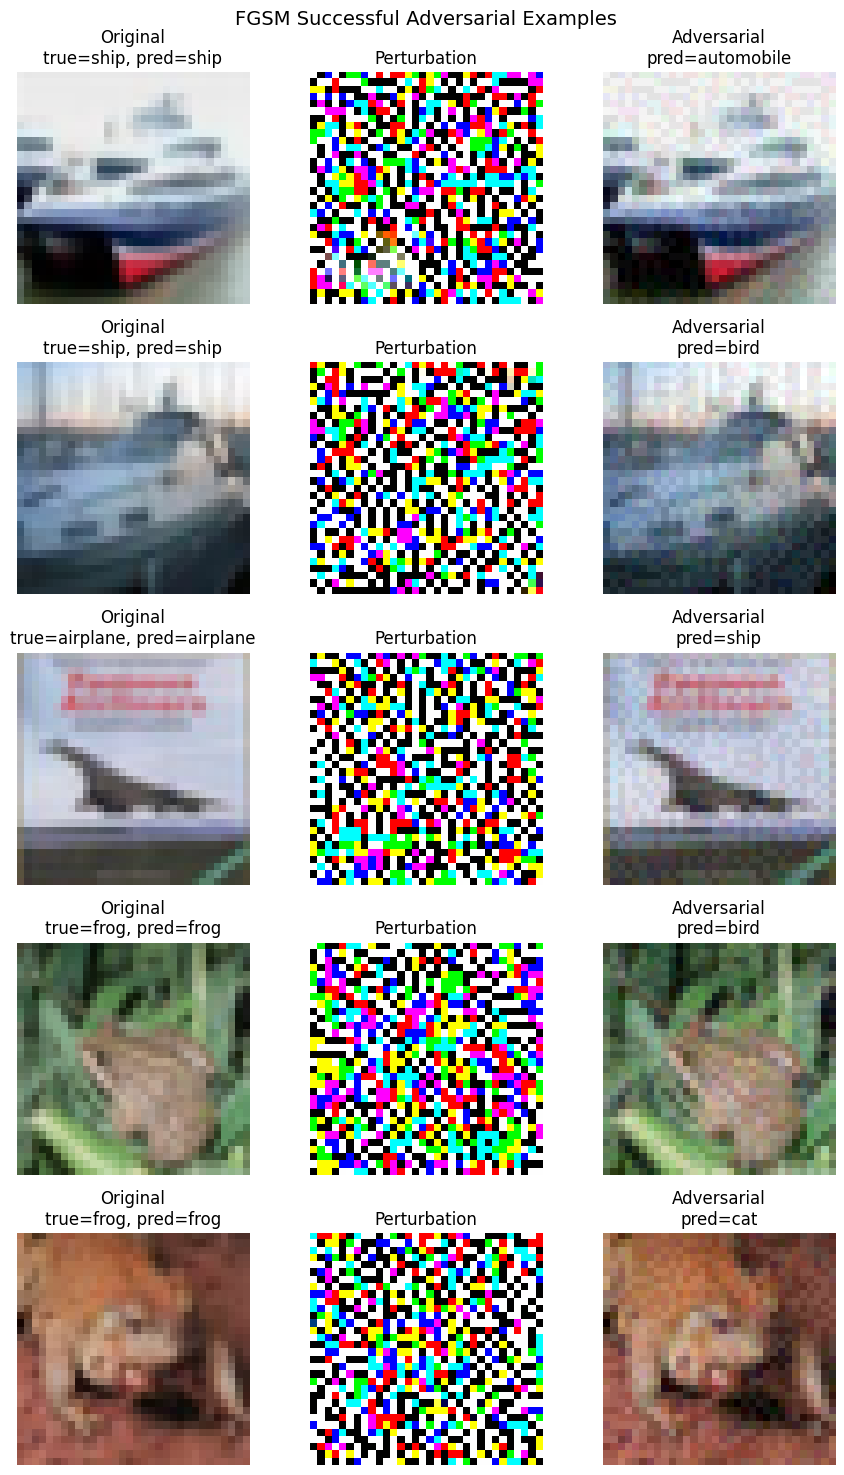

Saved: /content/q4_adversarial_outputs/fgsm_successful_examples.png


In [12]:
def tensor_to_image(tensor):
    return tensor.permute(1, 2, 0).numpy().clip(0.0, 1.0)


def tensor_to_noise_image(delta, epsilon):
    noise = delta / (2 * epsilon) + 0.5
    return noise.permute(1, 2, 0).numpy().clip(0.0, 1.0)


def show_adversarial_examples(examples, title, filename, epsilon=EPSILON):
    n = len(examples)
    fig, axes = plt.subplots(n, 3, figsize=(9, 3 * n))

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, example in enumerate(examples):
        original = tensor_to_image(example["original"])
        noise = tensor_to_noise_image(example["delta"], epsilon)
        adversarial = tensor_to_image(example["adversarial"])

        true_name = class_names[example["true_label"]]
        clean_name = class_names[example["clean_pred"]]
        adv_name = class_names[example["adv_pred"]]

        axes[i, 0].imshow(original)
        axes[i, 0].set_title(f"Original\ntrue={true_name}, pred={clean_name}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(noise)
        axes[i, 1].set_title("Perturbation")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(adversarial)
        axes[i, 2].set_title(f"Adversarial\npred={adv_name}")
        axes[i, 2].axis("off")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()

    path = os.path.join(OUTPUT_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", path)


show_adversarial_examples(
    fgsm_examples,
    "FGSM Successful Adversarial Examples",
    "fgsm_successful_examples.png",
    epsilon=EPSILON
)

<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل حمله FGSM</h3>

<p>
نتایج FGSM نشان می‌دهد که با اضافه کردن نویز کوچکی به اندازه epsilon = 8/255، دقت مدل به شدت کاهش پیدا کرده است. این نویز از نظر بصری معمولاً بسیار کم است، اما چون در جهت افزایش loss مدل ساخته می‌شود، می‌تواند تصمیم مدل را تغییر دهد.
</p>

<p>
افت دقت پس از FGSM نشان می‌دهد که مدل پایه با وجود عملکرد خوب روی تصاویر تمیز، نسبت به حملات گرادیانی آسیب‌پذیر است. بنابراین مرز تصمیم مدل در اطراف برخی تصاویر بسیار حساس است و تغییرات کوچک در پیکسل‌ها می‌تواند باعث پیش‌بینی اشتباه شود.
</p>

</div>

<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل نمونه‌های خصمانه FGSM</h3>

<p>
در نمونه‌های نمایش‌داده‌شده، هر ردیف شامل تصویر اصلی، نویز تولیدشده و تصویر خصمانه نهایی است. مدل تصویر اصلی را درست طبقه‌بندی کرده، اما پس از اضافه شدن نویز FGSM، پیش‌بینی مدل تغییر کرده و اشتباه شده است.
</p>

<p>
این نتیجه نشان می‌دهد که تغییرات کوچک و هدفمند در سطح پیکسل می‌توانند مدل را فریب دهند، حتی زمانی که تصویر خصمانه برای انسان هنوز بسیار شبیه تصویر اصلی به نظر می‌رسد.
</p>

</div>

## PGD Attack

PGD is an iterative adversarial attack. At each iteration, the image is updated in the direction of the gradient sign. Then, the perturbation is projected back into the allowed epsilon-ball around the original image, and the adversarial image is clipped to the valid pixel range.

In [13]:
def pgd_attack(model, images, labels, epsilon=EPSILON, alpha=ALPHA, steps=PGD_STEPS):
    was_training = model.training
    model.eval()

    x_original = images.detach().clone().to(DEVICE)
    y = labels.detach().clone().to(DEVICE)

    x_adv = x_original.clone().detach()

    for _ in range(steps):
        x_adv.requires_grad_(True)

        logits = model(x_adv)
        loss = F.cross_entropy(logits, y)

        grad = torch.autograd.grad(loss, x_adv)[0]

        x_adv = x_adv.detach() + alpha * grad.sign()
        delta = torch.clamp(x_adv - x_original, min=-epsilon, max=epsilon)
        x_adv = torch.clamp(x_original + delta, 0.0, 1.0).detach()

    if was_training:
        model.train()

    return x_adv

## Evaluate PGD Attack

The PGD attack is applied to the test set using epsilon = 8/255, alpha = 2/255, and 10 iterations. PGD is expected to be stronger than FGSM because it performs multiple projected updates.

In [14]:
pgd_acc, pgd_loss, pgd_examples = evaluate_attack(
    baseline_model,
    test_loader,
    lambda model, x, y: pgd_attack(
        model,
        x,
        y,
        epsilon=EPSILON,
        alpha=ALPHA,
        steps=PGD_STEPS
    ),
    examples_needed=5
)

attack_summary_df = pd.DataFrame([
    {
        "model": "Pretrained ResNet-20",
        "data": "Clean test",
        "accuracy": clean_acc,
        "loss": clean_loss
    },
    {
        "model": "Pretrained ResNet-20",
        "data": "FGSM test",
        "accuracy": fgsm_acc,
        "loss": fgsm_loss
    },
    {
        "model": "Pretrained ResNet-20",
        "data": "PGD test",
        "accuracy": pgd_acc,
        "loss": pgd_loss
    }
])

display(attack_summary_df)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Attack evaluation:   0%|          | 0/79 [00:00<?, ?it/s]

,model,data,accuracy,loss
0,Pretrained ResNet-20,Clean test,0.9260,0.281522
1,Pretrained ResNet-20,FGSM test,0.1498,6.513698
2,Pretrained ResNet-20,PGD test,0.0000,39.724970


## Visualize PGD Adversarial Examples

Five successful PGD adversarial examples are displayed. Each row shows the original image, the perturbation, and the final adversarial image.

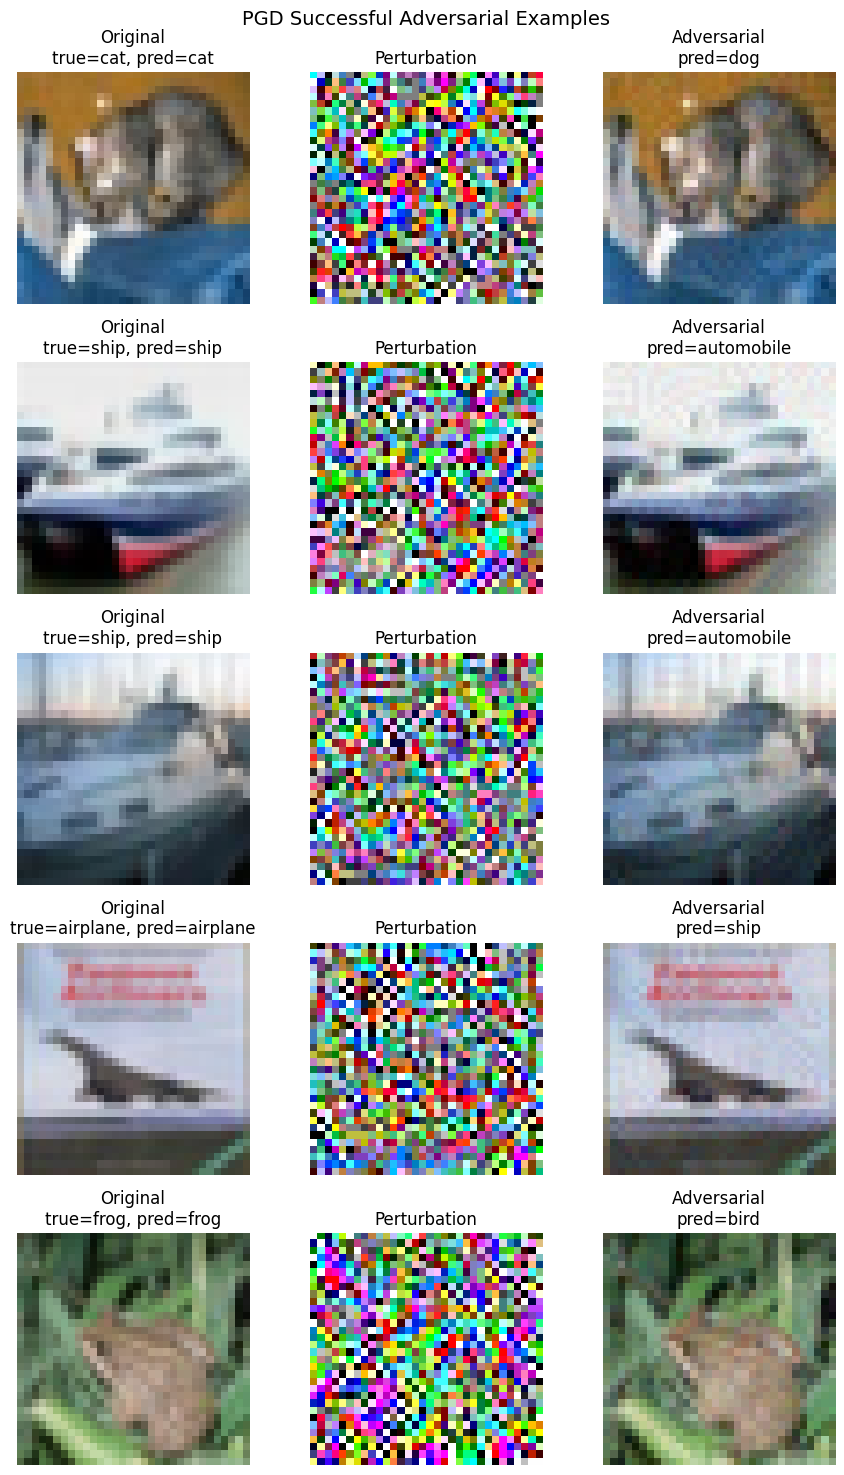

Saved: /content/q4_adversarial_outputs/pgd_successful_examples.png


In [15]:
show_adversarial_examples(
    pgd_examples,
    "PGD Successful Adversarial Examples",
    "pgd_successful_examples.png",
    epsilon=EPSILON
)


<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل نمونه‌های خصمانه PGD</h3>

<p>
در نمونه‌های PGD نیز مشاهده می‌شود که مدل تصویر اصلی را درست تشخیص داده، اما پس از اعمال حمله، پیش‌بینی آن تغییر کرده است. نویز PGD به صورت تکراری تولید شده و در هر مرحله تلاش می‌کند loss مدل را بیشتر کند.
</p>

<p>
این نمونه‌ها نشان می‌دهند که حتی اگر تغییر تصویر برای انسان کم به نظر برسد، مدل ممکن است ویژگی‌های بسیار حساسی را برای تصمیم‌گیری استفاده کند. به همین دلیل، مدل‌های عمیق در برابر حملات خصمانه می‌توانند شکننده باشند.
</p>

</div>

## Compare Clean, FGSM, and PGD Accuracy

This plot compares the accuracy of the pretrained model on clean images, FGSM adversarial images, and PGD adversarial images.

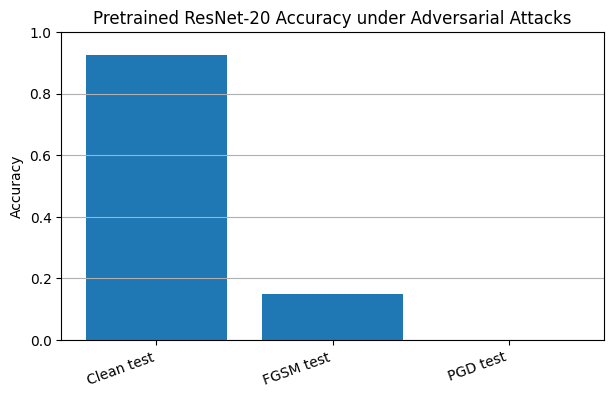

Saved: /content/q4_adversarial_outputs/baseline_attack_accuracy_comparison.png


In [16]:
plt.figure(figsize=(7, 4))

plt.bar(
    attack_summary_df["data"],
    attack_summary_df["accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Pretrained ResNet-20 Accuracy under Adversarial Attacks")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y")

attack_plot_path = os.path.join(OUTPUT_DIR, "baseline_attack_accuracy_comparison.png")
plt.savefig(attack_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", attack_plot_path)

<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل نمودار دقت مدل پایه تحت حملات خصمانه</h3>

<p>
نمودار نشان می‌دهد که دقت مدل پایه روی داده تمیز حدود 0.92 است، اما با حمله FGSM به حدود 0.15 کاهش پیدا می‌کند. در حمله PGD، دقت تقریباً به صفر نزدیک می‌شود. این افت شدید نشان می‌دهد که مدل پایه در برابر نویزهای کوچک اما هدفمند مقاوم نیست.
</p>

<p>
این نتیجه اهمیت ارزیابی robustness را نشان می‌دهد. مدلی که فقط روی داده تمیز دقت بالایی دارد، الزاماً در برابر ورودی‌های دستکاری‌شده قابل اعتماد نیست. بنابراین در مسائل حساس، بررسی عملکرد مدل تحت حملات خصمانه ضروری است.
</p>

</div>

## Adversarial Training Setup

A new copy of the pretrained ResNet-20 model is fine-tuned with adversarial training. In each training batch, 50% of the images are replaced with FGSM adversarial examples. The model is then trained on the mixed clean and adversarial batch.

In [17]:
adv_backbone = load_resnet20_cifar10()
adv_model = PixelModel(
    adv_backbone,
    CIFAR10_MEAN,
    CIFAR10_STD
).to(DEVICE)

optimizer = optim.SGD(
    adv_model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=5e-4
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=ADV_TRAIN_EPOCHS
)

criterion = nn.CrossEntropyLoss()

print("Adversarial training model is ready.")

Adversarial training model is ready.


Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


## Adversarial Training Loop

This function trains the model for one epoch. Half of each batch is attacked using FGSM, and the model is optimized on the mixed batch of clean and adversarial images.

In [18]:
def train_adversarial_epoch(model, loader, optimizer, adv_ratio=ADV_RATIO):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for images, labels in tqdm(loader, desc="Adversarial training"):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        mask = torch.rand(images.size(0), device=DEVICE) < adv_ratio

        mixed_images = images.detach().clone()

        if mask.any():
            attacked_images = fgsm_attack(
                model,
                images[mask],
                labels[mask],
                epsilon=EPSILON
            )
            mixed_images[mask] = attacked_images

        model.train()

        optimizer.zero_grad()

        logits = model(mixed_images)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        preds = logits.argmax(dim=1)

        total_loss += loss.item() * images.size(0)
        total_correct += (preds == labels).sum().item()
        total_count += images.size(0)

    return total_loss / total_count, total_correct / total_count

## Train the Adversarially Trained Model

The model is fine-tuned for a small number of epochs using adversarial training. The training loss is stored so that the loss curve can be plotted.

In [19]:
adv_train_history = []

for epoch in range(1, ADV_TRAIN_EPOCHS + 1):
    train_loss, train_acc = train_adversarial_epoch(
        adv_model,
        train_loader,
        optimizer,
        adv_ratio=ADV_RATIO
    )

    scheduler.step()

    clean_epoch_acc, clean_epoch_loss = evaluate_clean(
        adv_model,
        test_loader
    )

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "clean_test_loss": clean_epoch_loss,
        "clean_test_acc": clean_epoch_acc
    }

    adv_train_history.append(row)

    print(
        f"Epoch {epoch}/{ADV_TRAIN_EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"train_acc={train_acc:.4f} | "
        f"clean_test_acc={clean_epoch_acc:.4f}"
    )

adv_train_history_df = pd.DataFrame(adv_train_history)

history_path = os.path.join(OUTPUT_DIR, "adversarial_training_history.csv")
adv_train_history_df.to_csv(history_path, index=False)

display(adv_train_history_df)

print("Saved:", history_path)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Adversarial training:   0%|          | 0/157 [00:00<?, ?it/s]

Clean evaluation:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 1/3 | train_loss=1.1844 | train_acc=0.5848 | clean_test_acc=0.8619


Adversarial training:   0%|          | 0/157 [00:00<?, ?it/s]

...

Adversarial training:   0%|          | 0/157 [00:00<?, ?it/s]

Clean evaluation:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 3/3 | train_loss=0.7137 | train_acc=0.7410 | clean_test_acc=0.8861


,epoch,train_loss,train_acc,clean_test_loss,clean_test_acc
0,1,1.184438,0.58480,0.410668,0.8619
1,2,0.849417,0.68435,0.410562,0.8659
2,3,0.713652,0.74100,0.353584,0.8861


Saved: /content/q4_adversarial_outputs/adversarial_training_history.csv


## Training Loss Curve

The training loss curve is plotted to show how the adversarial training process evolves over epochs.

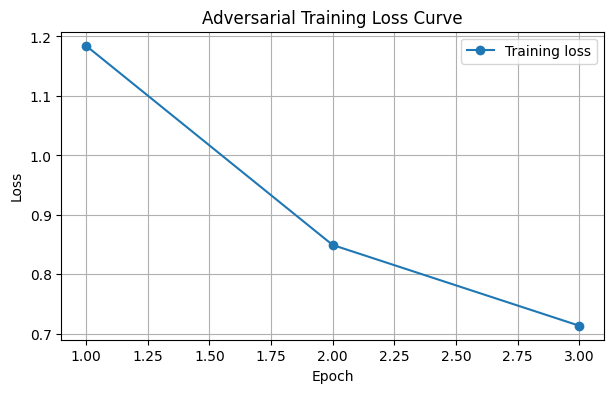

Saved: /content/q4_adversarial_outputs/adversarial_training_loss_curve.png


In [20]:
plt.figure(figsize=(7, 4))

plt.plot(
    adv_train_history_df["epoch"],
    adv_train_history_df["train_loss"],
    marker="o",
    label="Training loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Adversarial Training Loss Curve")
plt.grid(True)
plt.legend()

loss_plot_path = os.path.join(OUTPUT_DIR, "adversarial_training_loss_curve.png")
plt.savefig(loss_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", loss_plot_path)

<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل فرآیند آموزش خصمانه</h3>

<p>
در فرآیند adversarial training، حدود ۵۰ درصد تصاویر هر batch با روش FGSM به نمونه خصمانه تبدیل شدند و مدل روی ترکیبی از تصاویر تمیز و خصمانه آموزش دید. هدف این کار آن است که مدل مرز تصمیم مقاوم‌تری یاد بگیرد.
</p>

<p>
کاهش train loss از 1.1844 به 0.7137 نشان می‌دهد که فرآیند آموزش پایدار بوده و مدل در طول epochها بهتر شده است. همچنین دقت مدل روی داده تمیز پس از آموزش همچنان مقدار قابل قبولی دارد، بنابراین آموزش خصمانه باعث تخریب شدید عملکرد روی داده تمیز نشده است.
</p>

</div>

## Evaluate the Adversarially Trained Model

The adversarially trained model is evaluated on clean test data, FGSM adversarial test data, and PGD adversarial test data. These results are compared with the pretrained baseline model.

In [21]:
adv_clean_acc, adv_clean_loss = evaluate_clean(
    adv_model,
    test_loader
)

adv_fgsm_acc, adv_fgsm_loss, adv_fgsm_examples = evaluate_attack(
    adv_model,
    test_loader,
    lambda model, x, y: fgsm_attack(model, x, y, epsilon=EPSILON),
    examples_needed=5
)

adv_pgd_acc, adv_pgd_loss, adv_pgd_examples = evaluate_attack(
    adv_model,
    test_loader,
    lambda model, x, y: pgd_attack(
        model,
        x,
        y,
        epsilon=EPSILON,
        alpha=ALPHA,
        steps=PGD_STEPS
    ),
    examples_needed=5
)

final_comparison_df = pd.DataFrame([
    {
        "model": "Pretrained baseline",
        "test_data": "Clean",
        "accuracy": clean_acc,
        "loss": clean_loss
    },
    {
        "model": "Pretrained baseline",
        "test_data": "FGSM",
        "accuracy": fgsm_acc,
        "loss": fgsm_loss
    },
    {
        "model": "Pretrained baseline",
        "test_data": "PGD",
        "accuracy": pgd_acc,
        "loss": pgd_loss
    },
    {
        "model": "Adversarially trained",
        "test_data": "Clean",
        "accuracy": adv_clean_acc,
        "loss": adv_clean_loss
    },
    {
        "model": "Adversarially trained",
        "test_data": "FGSM",
        "accuracy": adv_fgsm_acc,
        "loss": adv_fgsm_loss
    },
    {
        "model": "Adversarially trained",
        "test_data": "PGD",
        "accuracy": adv_pgd_acc,
        "loss": adv_pgd_loss
    }
])

comparison_path = os.path.join(OUTPUT_DIR, "final_attack_comparison.csv")
final_comparison_df.to_csv(comparison_path, index=False)

display(final_comparison_df)

print("Saved:", comparison_path)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b269b8edf80>
Traceback (most recent call last):
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7b269b8edf80>    self._shutdown_workers()

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
        self._shutdown_workers()
if w.is_alive():
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
      if w.is_a

Clean evaluation:   0%|          | 0/79 [00:00<?, ?it/s]

^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
^AssertionError^: ^can only test a child process
^^^^
AssertionError: can only test a child process


Attack evaluation:   0%|          | 0/79 [00:00<?, ?it/s]

Attack evaluation:   0%|          | 0/79 [00:00<?, ?it/s]

,model,test_data,accuracy,loss
0,Pretrained baseline,Clean,0.9260,0.281522
1,Pretrained baseline,FGSM,0.1498,6.513698
2,Pretrained baseline,PGD,0.0000,39.724970
3,Adversarially trained,Clean,0.8861,0.353584
4,Adversarially trained,FGSM,0.5722,1.191113
5,Adversarially trained,PGD,0.0165,6.911282


Saved: /content/q4_adversarial_outputs/final_attack_comparison.csv


## Final Accuracy Comparison

This plot compares the pretrained baseline model and the adversarially trained model on clean, FGSM, and PGD test data.

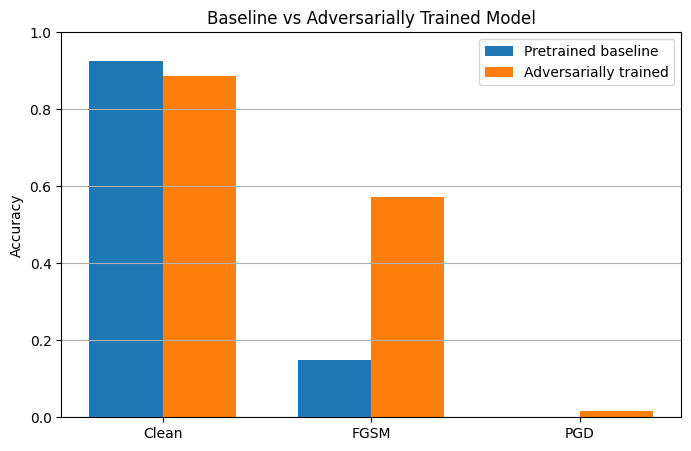

Saved: /content/q4_adversarial_outputs/baseline_vs_adversarial_training_accuracy.png


In [22]:
pivot_df = final_comparison_df.pivot(
    index="test_data",
    columns="model",
    values="accuracy"
)

plt.figure(figsize=(8, 5))

x = np.arange(len(pivot_df.index))
width = 0.35

plt.bar(
    x - width / 2,
    pivot_df["Pretrained baseline"],
    width,
    label="Pretrained baseline"
)

plt.bar(
    x + width / 2,
    pivot_df["Adversarially trained"],
    width,
    label="Adversarially trained"
)

plt.xticks(x, pivot_df.index)
plt.ylabel("Accuracy")
plt.title("Baseline vs Adversarially Trained Model")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y")

final_plot_path = os.path.join(OUTPUT_DIR, "baseline_vs_adversarial_training_accuracy.png")
plt.savefig(final_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", final_plot_path)

<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>تحلیل نمودار مقایسه نهایی</h3>

<p>
نمودار مقایسه نهایی نشان می‌دهد که مدل پایه روی داده تمیز بهترین دقت را دارد، اما در برابر FGSM و PGD به شدت افت می‌کند. در مقابل، مدل adversarially trained روی داده تمیز کمی ضعیف‌تر است، اما در برابر FGSM عملکرد بسیار بهتری دارد.
</p>

<p>
این نمودار trade-off بین accuracy و robustness را نشان می‌دهد. آموزش خصمانه معمولاً ممکن است کمی دقت clean را کاهش دهد، اما در عوض مدل را در برابر حملاتی که در زمان آموزش دیده است مقاوم‌تر می‌کند. در این آزمایش، این اثر برای FGSM واضح است، اما برای PGD هنوز کافی نیست.
</p>

</div>

## Save Important Artifacts

The main numerical results and figures are saved in the output directory. These files can be used in the final report or notebook submission.

In [23]:
print("Output directory:")
print(OUTPUT_DIR)

print("Saved files:")
for filename in sorted(os.listdir(OUTPUT_DIR)):
    print(filename)

Output directory:
/content/q4_adversarial_outputs
Saved files:
adversarial_training_history.csv
adversarial_training_loss_curve.png
baseline_attack_accuracy_comparison.png
baseline_vs_adversarial_training_accuracy.png
fgsm_successful_examples.png
final_attack_comparison.csv
pgd_successful_examples.png


<div dir="rtl" style="text-align: right; font-family: 'B Nazanin', 'BNazanin', 'Tahoma'; font-size: 16px; line-height: 2;">

<h3>جمع‌بندی نهایی پرسش ۴</h3>

<p>
در این پرسش، مدل ResNet-20 از پیش‌آموزش‌دیده روی CIFAR-10 ابتدا روی داده‌های تمیز ارزیابی شد و سپس تحت دو حمله FGSM و PGD قرار گرفت. نتایج نشان داد که مدل روی تصاویر تمیز دقت بالایی دارد، اما در برابر حملات خصمانه آسیب‌پذیر است.
</p>

<p>
حمله FGSM با یک گام گرادیانی توانست دقت مدل را به شدت کاهش دهد. حمله PGD نیز به دلیل ماهیت تکراری و استفاده از projection، حمله قوی‌تری ایجاد کرد و دقت مدل را تقریباً به صفر رساند. بنابراین دقت بالا روی داده تمیز به تنهایی برای اعتماد به مدل کافی نیست.
</p>

<p>
در مرحله مقاوم‌سازی، مدل با ترکیبی از داده‌های تمیز و نمونه‌های خصمانه FGSM آموزش داده شد. این روش باعث شد مقاومت مدل در برابر FGSM به شکل قابل توجهی افزایش یابد، در حالی که دقت روی داده تمیز فقط کمی کاهش پیدا کرد.
</p>

<p>
با این حال، مدل مقاوم‌شده همچنان در برابر PGD آسیب‌پذیر باقی ماند. دلیل اصلی این است که مدل در زمان آموزش فقط نمونه‌های FGSM را دیده بود و PGD حمله‌ای قوی‌تر و چندمرحله‌ای است. بنابراین برای افزایش مقاومت در برابر PGD، استفاده از PGD adversarial training یا ترکیب چند نوع حمله در آموزش پیشنهاد می‌شود.
</p>

</div>

# Conclusion

This experiment demonstrates that high accuracy on clean data does not guarantee robustness against adversarial attacks.

Key observations:

- FGSM and PGD attacks can significantly reduce model performance.
- Adversarial examples reveal vulnerabilities in deep learning systems.
- Adversarial training improves robustness against perturbations.

Robustness evaluation is an essential component of trustworthy machine learning systems.